<h3 style="color :blue;">Title:Demand Forecasting Project</h3>
<h4 style="color :blue;">Objective:</h4>
<p style="font-size:30px;color:black;">The objective of this project is to analyze business sales performance by examining revenue trends, evaluating product return patterns, and forecasting future product demand. The project aims to provide actionable insights that help improve decision-making, optimize inventory management, reduce return rates, and enhance overall business profitability.</p></h3>
<h4 style="color :blue;">Problem Statement:</h4>
<p style="font-size:30px;color:black;">Organizations generate large volumes of sales and transaction data, but converting this data into meaningful business insights remains a challenge. Understanding revenue performance, identifying products with high return rates, and accurately predicting future product demand are critical for effective business planning. Without proper analysis, businesses may face inventory shortages, excess stock, reduced profitability, and increased operational costs. This project addresses these challenges by analyzing revenue and product return data and developing a predictive model to estimate product units sold for the upcoming month, enabling data-driven business decisions.</p>

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("C:/Users/SAKEENA/Downloads/data Analytics/finance_project.csv")
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


<h3 style="color :blue;">Data Checking</h3>

In [3]:
df.isna().sum()

Date              0
Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.dtypes

Date               object
Product Name       object
Category           object
Units Sold          int64
Price             float64
Revenue           float64
Discount          float64
Units Returned      int64
Location           object
Platform           object
dtype: object

In [6]:
df['Date']=pd.to_datetime(df['Date'])

In [7]:
df.dtypes

Date              datetime64[ns]
Product Name              object
Category                  object
Units Sold                 int64
Price                    float64
Revenue                  float64
Discount                 float64
Units Returned             int64
Location                  object
Platform                  object
dtype: object

In [8]:
df.describe()

,Date,Units Sold,Price,Revenue,Discount,Units Returned
count,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,2022-08-18 12:00:00,150.200274,34.781229,5226.569446,0.124398,1.531478
min,2020-01-06 00:00:00,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,2021-04-26 00:00:00,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,2022-08-18 12:00:00,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,2023-12-11 00:00:00,158.000000,46.712500,7009.960000,0.190000,2.000000
max,2025-03-31 00:00:00,194.000000,59.970000,10761.850000,0.250000,8.000000
std,NaN,12.396099,14.198309,2192.491946,0.071792,1.258479


In [9]:
for col in df.columns:
    if df[col].nunique()<=10:
        print(f"Unique values in {col} are:")
        print(df[col].unique())
        print()

Unique values in Category are:
['Protein' 'Vitamin' 'Omega' 'Performance' 'Amino Acid' 'Mineral' 'Herbal'
 'Sleep Aid' 'Fat Burner' 'Hydration']

Unique values in Units Returned are:
[2 0 3 1 5 4 6 7 8]

Unique values in Location are:
['Canada' 'UK' 'USA']

Unique values in Platform are:
['Walmart' 'Amazon' 'iHerb']



In [10]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


<h3 style="color :blue;">Revenue Analysis</h3>

In [11]:
# which categories are been selling more
categories=df.groupby('Category')['Revenue'].sum().reset_index().sort_values(by='Revenue',ascending=False)
categories

,Category,Revenue
9,Vitamin,4300224.68
4,Mineral,4276107.99
6,Performance,2909702.18
7,Protein,2855492.09
0,Amino Acid,1464819.63
5,Omega,1451065.87
1,Fat Burner,1440900.05
3,Hydration,1411951.38
2,Herbal,1405700.79
8,Sleep Aid,1397315.79


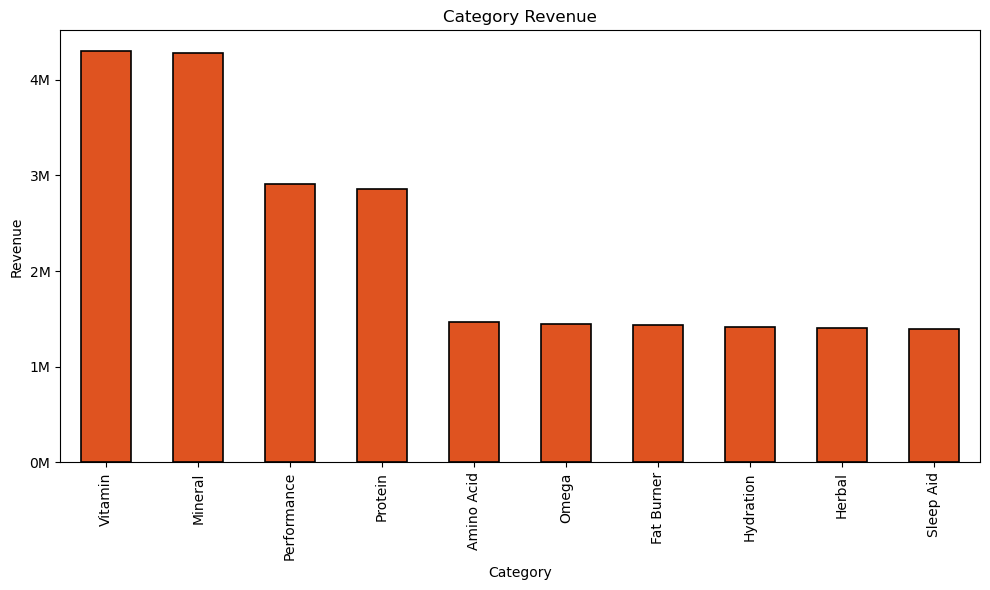

In [12]:
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=categories,x='Category',y='Revenue',color='#FF4400',
           width=0.55,edgecolor='black',linewidth=1.2,ax=ax)
ax.ticklabel_format(style='plain',axis='y')
plt.title('Category Revenue')
plt.xticks(rotation=90)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos: f'{x*1e-6:.0f}M'))
plt.tight_layout()
plt.show()

# Observations
Vitamin categories are given more revenue.Because under vitamin and mineral category we had 3 products. but for other categories we had only 1 or 2 products.

In [13]:
# category and product wise revenue
cat_pro_revenue=df.groupby(['Category','Product Name'])['Revenue'].sum()
cat_pro_revenue

Category     Product Name      
Amino Acid   BCAA                  1464819.63
Fat Burner   Green Tea Extract     1440900.05
Herbal       Ashwagandha           1405700.79
Hydration    Electrolyte Powder    1411951.38
Mineral      Iron Supplement       1431582.41
             Magnesium             1361978.63
             Zinc                  1482546.95
Omega        Fish Oil              1451065.87
Performance  Creatine              1432518.40
             Pre-Workout           1477183.78
Protein      Collagen Peptides     1433297.24
             Whey Protein          1422194.85
Sleep Aid    Melatonin             1397315.79
Vitamin      Biotin                1486798.62
             Multivitamin          1391427.99
             Vitamin C             1421998.07
Name: Revenue, dtype: float64

In [14]:
# productwise Revenue
Pro_revenue=df.groupby('Product Name')['Revenue'].sum().reset_index().sort_values(by='Revenue',ascending=False)

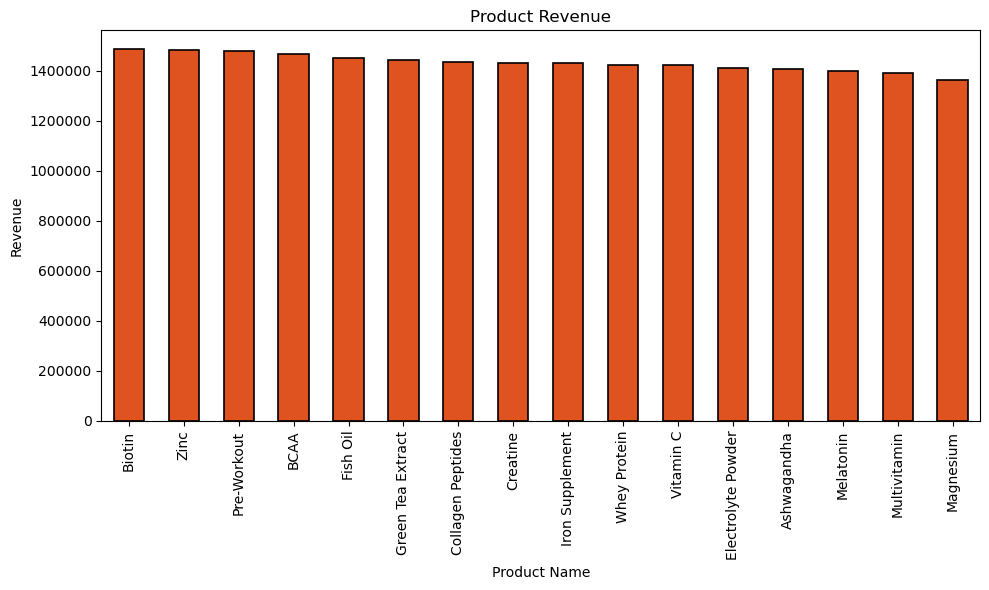

In [15]:
#visualize product wise revenue
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=Pro_revenue,x='Product Name',y='Revenue',color='#FF4400',
           width=0.55,edgecolor='black',linewidth=1.2,ax=ax)
ax.ticklabel_format(style='plain',axis='y')
plt.title('Product Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [16]:
# Location wise products revenue
Location_wise_pro=df.groupby(['Location','Product Name'])['Revenue'].sum().reset_index()
Location_wise_pro

,Location,Product Name,Revenue
0,Canada,Ashwagandha,412859.07
1,Canada,BCAA,455781.66
2,Canada,Biotin,401823.88
3,Canada,Collagen Peptides,518341.15
4,Canada,Creatine,604519.43
5,Canada,Electrolyte Powder,464208.60
6,Canada,Fish Oil,543713.40
7,Canada,Green Tea Extract,542900.94
8,Canada,Iron Supplement,480346.55
9,Canada,Magnesium,443258.25


In [17]:
# let's extract the high revenue products from each country
idx=Location_wise_pro.groupby('Location')['Revenue'].idxmax()
high_revenue_pro=Location_wise_pro.loc[idx]
high_revenue_pro

,Location,Product Name,Revenue
4,Canada,Creatine,604519.43
18,UK,Biotin,577049.68
32,USA,Ashwagandha,517023.57


In [18]:
# let's extract the least revenue products from each country.
min_idx=Location_wise_pro.groupby('Location')['Revenue'].idxmin()
low_products=Location_wise_pro.loc[min_idx]
low_products

,Location,Product Name,Revenue
2,Canada,Biotin,401823.88
26,UK,Melatonin,419310.84
36,USA,Creatine,383709.79


In [19]:
#Top 2 high sales from each country
top_2_sales=Location_wise_pro.groupby('Location').apply(lambda x:x.nlargest(2,'Revenue'))
top_2_sales.reset_index(drop=True)

,Location,Product Name,Revenue
0,Canada,Creatine,604519.43
1,Canada,Fish Oil,543713.40
2,UK,Biotin,577049.68
3,UK,BCAA,552018.61
4,USA,Ashwagandha,517023.57
5,USA,Iron Supplement,510298.92


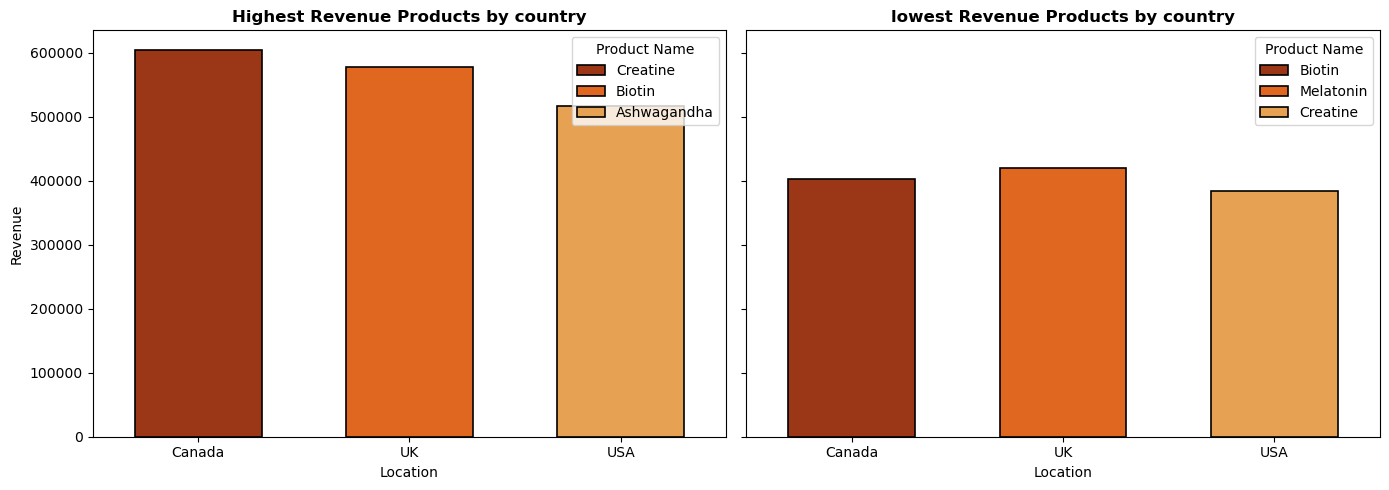

In [20]:
# visualize highest and lowest products by countrywise
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True)

high_colors=['#B12C00','#FF5F00','#FFA239']
low_colors=['#B12C00','#FF5F00','#FFA239']
sns.barplot(data=high_revenue_pro,x='Location',y='Revenue',hue='Product Name',
            ax=axes[0],palette=high_colors,width=0.6,edgecolor='black',linewidth=1.2)
axes[0].set_title('Highest Revenue Products by country',fontsize=12,
                  fontweight='bold')
axes[0].set_ylabel('Revenue')

sns.barplot(data=low_products,x='Location',y='Revenue',hue='Product Name',
            ax=axes[1],palette=low_colors,width=0.6,edgecolor='black',linewidth=1.2)
axes[1].set_title('lowest Revenue Products by country',fontsize=12,
                  fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

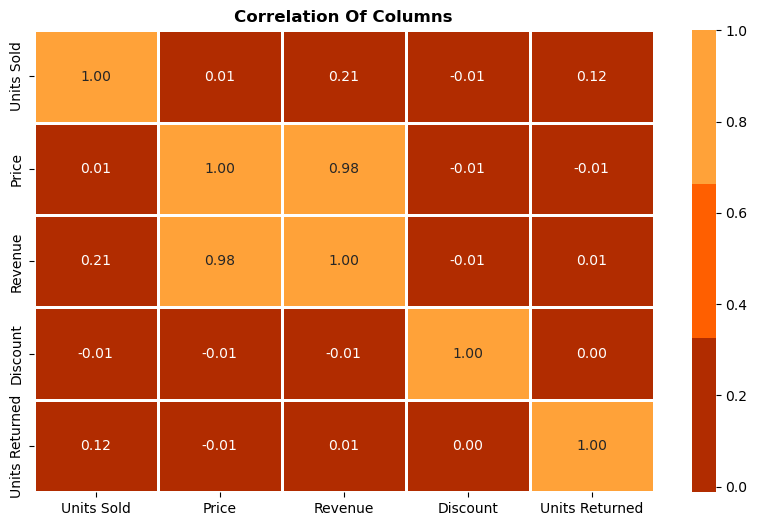

In [21]:
# correlation of numerical columns
orange_colors=['#B12C00','#FF5F00','#FFA239']
orange_cmap=sns.color_palette(orange_colors,as_cmap=True)
data=df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(data,annot=True,fmt=".2f",cmap=orange_cmap,linewidth=1,linecolor='white')
plt.title('Correlation Of Columns',fontweight='bold')
plt.show()
plt.show()

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">No Correlation between the discount and units returned.</p>

In [22]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


<h3 style="color :blue;">Return Analysis</h3>

In [23]:
# returns by platform
df.groupby('Platform')['Units Returned'].sum()

Platform
Amazon     2295
Walmart    2128
iHerb      2291
Name: Units Returned, dtype: int64

In [24]:
#returns from the platforms of the each country
df.groupby(['Location','Platform'])['Units Returned'].sum()

Location  Platform
Canada    Amazon      774
          Walmart     720
          iHerb       765
UK        Amazon      746
          Walmart     763
          iHerb       818
USA       Amazon      775
          Walmart     645
          iHerb       708
Name: Units Returned, dtype: int64

# observations:
In canada and USA we have more returns from Amazon platform. So from Amazon we had more returns.

In [25]:
# let's know which products  are having more returns
df.groupby('Product Name')['Units Returned'].sum().sort_values(ascending=False)

Product Name
Vitamin C             457
Electrolyte Powder    441
Magnesium             431
BCAA                  428
Collagen Peptides     427
Iron Supplement       426
Pre-Workout           426
Multivitamin          425
Green Tea Extract     417
Creatine              415
Biotin                411
Whey Protein          409
Melatonin             408
Fish Oil              407
Zinc                  394
Ashwagandha           392
Name: Units Returned, dtype: int64

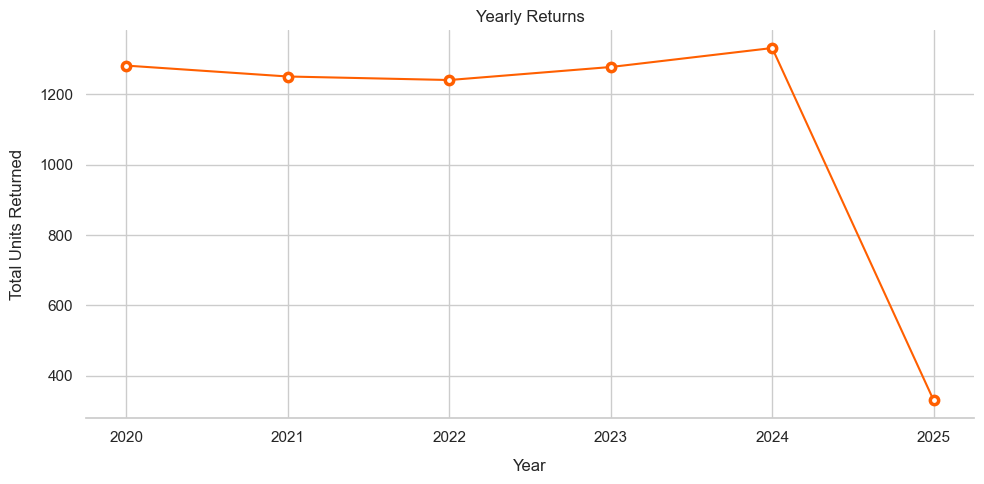

In [26]:
# visualize yearly returns
sns.set_theme(style='whitegrid')
fig,ax=plt.subplots(figsize=(10,5))
yearly_returns=df.groupby(df['Date'].dt.year)['Units Returned'].sum()
yearly_returns.plot(kind='line',marker='o',
                    markerfacecolor='white',markeredgewidth=2.5,
                    ax=ax,color='#FF5F00')
plt.title('Yearly Returns')
plt.xlabel('Year',fontsize=12,labelpad=10)
plt.ylabel('Total Units Returned',fontsize=12,labelpad=10)
sns.despine(left=True,bottom=False)
plt.tight_layout()
plt.show()

# Observations:
There is no sharp reduction in the returns. but as compared to other years, 2022 is having slightly low returns. As we have only 3 months of data in 2025 the return drops.

In [27]:
df['Return Rate']=(df['Units Returned']/df['Units Sold'])*100
df.groupby('Platform')['Return Rate'].mean()

Platform
Amazon     1.040318
Walmart    0.999386
iHerb      1.015324
Name: Return Rate, dtype: float64

In [28]:
# monthly Revenue
monthly_revenue=df.groupby(pd.Grouper(key='Date',freq="ME"))['Revenue'].sum().reset_index()
monthly_revenue

,Date,Revenue
0,2020-01-31,290723.89
1,2020-02-29,355213.26
2,2020-03-31,416547.17
3,2020-04-30,326287.92
4,2020-05-31,333210.99
...,...,...
58,2024-11-30,329894.33
59,2024-12-31,446728.99
60,2025-01-31,304965.15
61,2025-02-28,341768.25


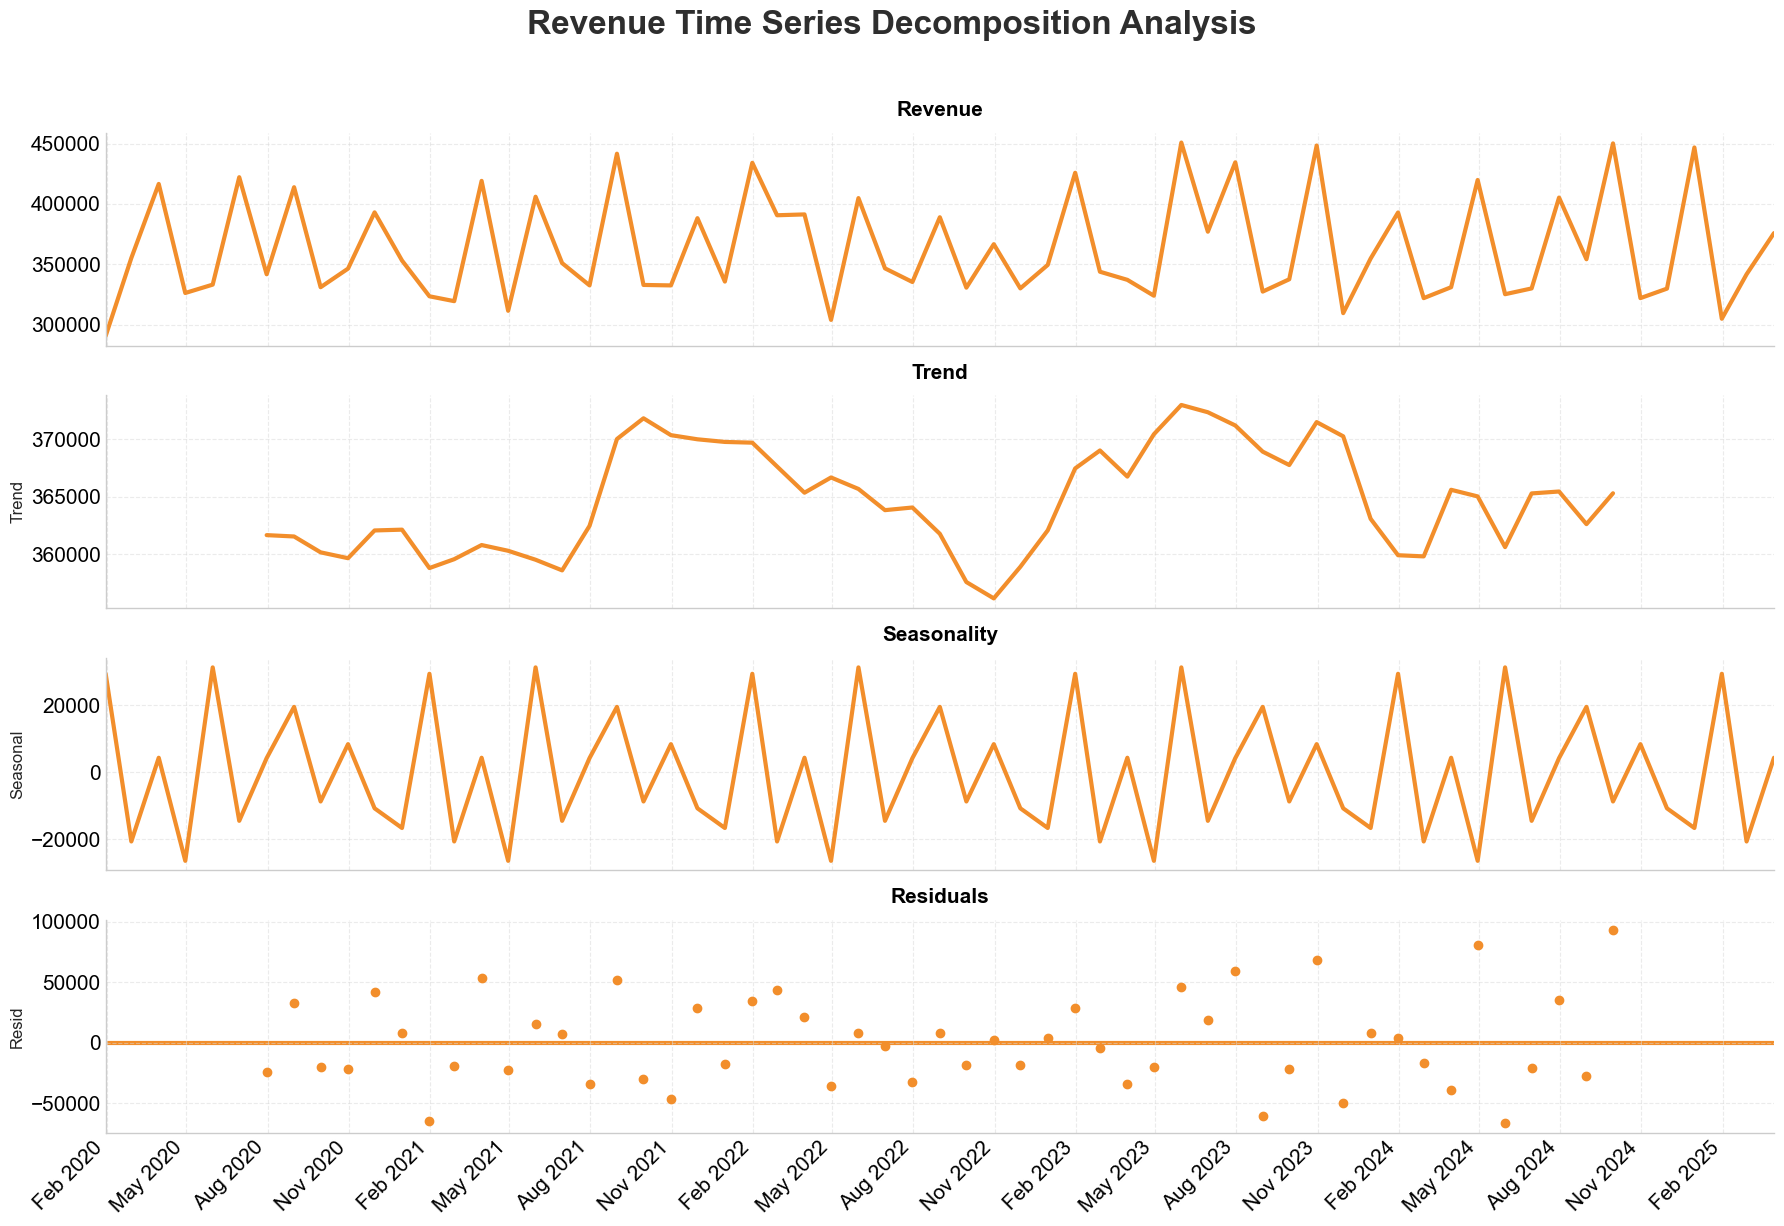

In [29]:
# visualize trend,seasonality,noise of revenue
monthly_revenue=monthly_revenue.set_index('Date')
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(monthly_revenue['Revenue'], model='additive',
                            period=12)

plt.style.use('seaborn-v0_8-whitegrid')

ORANGE = "#F28E2B"
DARK_GRAY = "#2E2E2E"
GRID = "#D9D9D9"
BG = "#FFFFFF"

fig = result.plot()
# Figure size
fig.set_size_inches(18, 12)
axes = fig.axes
titles = [
    "Revenue",
    "Trend",
    "Seasonality",
    "Residuals"
]

for i, ax in enumerate(axes):
    # Background
    ax.set_facecolor(BG)
    # Grid
    ax.grid(
        True,
        linestyle='--',
        linewidth=0.8,
        alpha=0.5,
        color=GRID
    )
    # Remove unnecessary borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Improve lines
    for line in ax.get_lines():
        line.set_color(ORANGE)
        line.set_linewidth(3)
    # Residual scatter
    for collection in ax.collections:
        collection.set_color(ORANGE)
        collection.set_alpha(0.8)
    # Axis formatting
    ax.tick_params(
        axis='both',
        labelsize=15,
        colors='black'
    )
    # Subplot title
    ax.set_title(
        titles[i],
        fontsize=15,
        fontweight='bold',
        color='black',
        pad=12
    )
    # Month-Year formatting
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=3)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha='right'
    )
fig.suptitle(
    "Revenue Time Series Decomposition Analysis",
    fontsize=24,
    fontweight='bold',
    color=DARK_GRAY,
    y=1.02
)
plt.tight_layout()
plt.show()

# Obserations
# Trend:
There is stable trend till mid 2021 and after that trend has increased, and then recovered in 2023 again.In mid 2023 there is stable trend again.
# Seasonality:
The peaks and drops appear regularly.
# Residulas:
Most points are close to zero. But some large positive and negative spikes exist.

In [30]:
# Which month we have more sales?
m=df.groupby(df['Date'].dt.month)['Revenue'].mean()
m.sort_values(ascending=False)

Date
12    5475.971756
6     5437.135119
2     5398.559479
9     5304.873810
3     5257.005556
7     5254.067727
8     5233.672772
5     5217.611984
10    5159.207841
1     5027.699190
4     5016.852083
11    4973.839659
Name: Revenue, dtype: float64

In [31]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,1.398601
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,1.910828


<h3 style="color :blue;">Predicting the last month of data</h3>

In [32]:
# Product data
temp = (
        df[df['Product Name'] =='Whey Protein']
        .groupby('Date')['Units Sold']
        .sum()
        .reset_index()
        .sort_values('Date')
    )

In [33]:
temp

,Date,Units Sold
0,2020-01-06,143
1,2020-01-13,150
2,2020-01-20,157
3,2020-01-27,137
4,2020-02-03,165
...,...,...
269,2025-03-03,160
270,2025-03-10,140
271,2025-03-17,166
272,2025-03-24,158


In [34]:
# extracting all the dates
full_dates = pd.date_range(
        start=temp['Date'].min(),
        end=temp['Date'].max(),
        freq='D'
    )
full_dates

DatetimeIndex(['2020-01-06', '2020-01-07', '2020-01-08', '2020-01-09',
               '2020-01-10', '2020-01-11', '2020-01-12', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-03-22', '2025-03-23', '2025-03-24', '2025-03-25',
               '2025-03-26', '2025-03-27', '2025-03-28', '2025-03-29',
               '2025-03-30', '2025-03-31'],
              dtype='datetime64[ns]', length=1912, freq='D')

In [35]:
# filling missing dates and fill sales zero in that missing dates.
temp = (
        temp.set_index('Date')
            .reindex(full_dates)
            .fillna(0)  # Fill missing dates with 0 sales
            .rename_axis('Date')
            .reset_index()
    )

temp.columns = ['Date', 'Units Sold']
if len(temp) < 60:
    print("Warning: Dataset contains fewer than 60 records.Skipping final processing")
else:
    print("Dataset Validation Successful. Proceeding with analysis...")

Dataset Validation Successful. Proceeding with analysis...


In [36]:
temp

,Date,Units Sold
0,2020-01-06,143.0
1,2020-01-07,0.0
2,2020-01-08,0.0
3,2020-01-09,0.0
4,2020-01-10,0.0
...,...,...
1907,2025-03-27,0.0
1908,2025-03-28,0.0
1909,2025-03-29,0.0
1910,2025-03-30,0.0


In [37]:
# predicting the last month of the data to check the accuracy.
# Train/Test split
train = temp.iloc[:-30]
test = temp.iloc[-30:]

In [38]:
# Facebook's prophet library cannot accept arbitrary column names. so changing 
# the column names.
train_prophet = train.rename(
        columns={
            'Date': 'ds',
            'Units Sold': 'y'
        }
    )


In [39]:
 # Train model
# here are taking weekly_seasonality. beacause our data is weekly data.

model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False
    )
# train the data on our history

model.fit(train_prophet)

14:39:39 - cmdstanpy - INFO - Chain [1] start processing
14:39:40 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
# Predict next 30 days (which correspond to test set)
future = model.make_future_dataframe(periods=30)

#generating the predictions.
forecast = model.predict(future)

# extracting last 30 days
pred = forecast['yhat'].tail(30).values


In [41]:
 # Avoid negative sales predictions
pred = np.maximum(pred, 0)

actual = test['Units Sold'].values


In [42]:
# let's calculate the accuracy metrics
results = []
all_forecasts = {}
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

non_zero = actual != 0
if non_zero.sum() > 0:
    mape = (
        np.abs((actual[non_zero] - pred[non_zero]) /
                actual[non_zero])
    ).mean() * 100
else:
    mape = np.nan

results.append({
    'Product': 'Whey Protein',
    'MAE': round(mae, 2),
    'RMSE': round(rmse, 2),
    'MAPE': round(mape, 2),
    'actual':sum(actual),
    'pred':sum(pred)
})

In [43]:
results_df = pd.DataFrame(results)

print(results_df.sort_values('MAPE'))

        Product   MAE  RMSE  MAPE  actual        pred
0  Whey Protein  1.88  4.04   5.8   772.0  766.332431


In [44]:
# Save forecast comparison
comparison = test.copy()
comparison['Predicted'] = pred
product='Whey Protein'
all_forecasts[product] = comparison

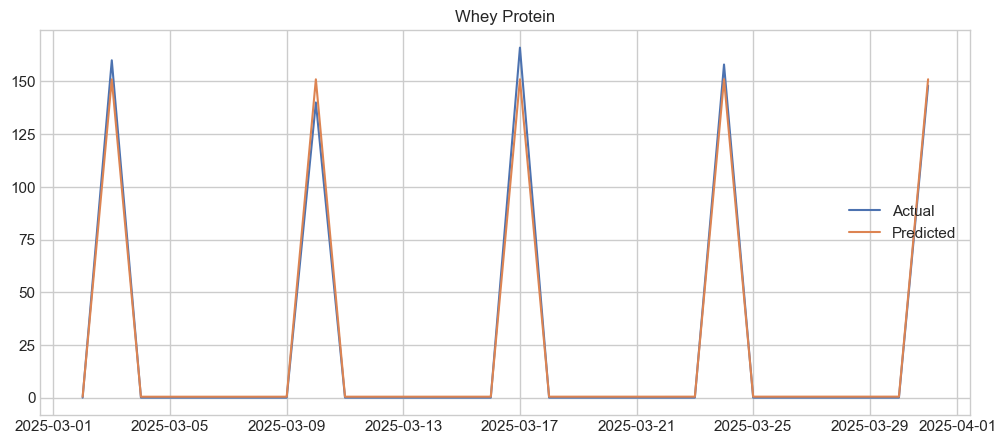

In [45]:
# visualizing the prediction for whey protein product.
product = 'Whey Protein'

comp = all_forecasts[product]

plt.figure(figsize=(12,5))
plt.plot(comp['Date'], comp['Units Sold'], label='Actual')
plt.plot(comp['Date'], comp['Predicted'], label='Predicted')
plt.title(product)
plt.legend()
plt.show()

In [46]:
print(all_forecasts['Whey Protein'])

           Date  Units Sold   Predicted
1882 2025-03-02         0.0    0.437085
1883 2025-03-03       160.0  150.966641
1884 2025-03-04         0.0    0.439748
1885 2025-03-05         0.0    0.440778
1886 2025-03-06         0.0    0.441803
1887 2025-03-07         0.0    0.442826
1888 2025-03-08         0.0    0.443852
1889 2025-03-09         0.0    0.446640
1890 2025-03-10       140.0  150.976197
1891 2025-03-11         0.0    0.449304
1892 2025-03-12         0.0    0.450334
1893 2025-03-13         0.0    0.451358
1894 2025-03-14         0.0    0.452382
1895 2025-03-15         0.0    0.453408
1896 2025-03-16         0.0    0.456196
1897 2025-03-17       166.0  150.985752
1898 2025-03-18         0.0    0.458859
1899 2025-03-19         0.0    0.459889
1900 2025-03-20         0.0    0.460914
1901 2025-03-21         0.0    0.461937
1902 2025-03-22         0.0    0.462963
1903 2025-03-23         0.0    0.465751
1904 2025-03-24       158.0  150.995307
1905 2025-03-25         0.0    0.468414


# Observations
- we forcast the last month units sold of our data, to check whether the model is working well or not.As MAPE is <10% , The Accuracy is very good. The predicted values are very close to the actual values.
# why to choose Prophet model?
Because this data is having clear trend and seasonality. Prophet is highly effictive for business time-series forecasting as it
* Automatically handles trend changes,seasonality.
* Missing values and irregular fluctuations.
while providing interpretable forecasting components.

<h3 style="color :blue;">Predicting the Next Month Sales of Products.</h3>

In [84]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

results = []

products = df['Product Name'].unique()

for product in products:

    # Product-wise daily sales
    temp = (
        df[df['Product Name'] == product]
        .groupby('Date')['Units Sold']
        .sum()
        .reset_index()
        .sort_values('Date')
    )

    # Skip products with very few records
    if len(temp) < 60:
        continue

    # Fill missing dates with 0 sales
    temp = (
        temp.set_index('Date')
        .asfreq('D', fill_value=0)
        .reset_index()
    )

    # Prophet format
    prophet_df = temp.rename(
        columns={
            'Date': 'ds',
            'Units Sold': 'y'
        }
    )

    # Train-Test Split (Last 30 days for testing)
    train = prophet_df[:-30]
    test = prophet_df[-30:]

    # Train Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(train)

    # Predict Test Period
    future_test = model.make_future_dataframe(
        periods=30,
        freq='D'
    )

    forecast_test = model.predict(future_test)

    pred = forecast_test.tail(30)['yhat'].values
    actual = test['y'].values

    # Evaluation Metrics
    mae = mean_absolute_error(actual, pred)

    rmse = np.sqrt(
        mean_squared_error(actual, pred)
    )

    mape = np.mean(
        np.abs((actual - pred) /
               np.where(actual == 0, 1, actual))
    ) * 100

    wmape = (
        np.sum(np.abs(actual - pred))
        / np.sum(actual)
    ) * 100 if np.sum(actual) != 0 else np.nan

    # Forecast Next 30 Days
    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    final_model.fit(prophet_df)

    future = final_model.make_future_dataframe(
        periods=30,
        freq='D'
    )

    forecast = final_model.predict(future)

    next_month_forecast = int(
        round(
            forecast.tail(30)['yhat'].sum()
        )
    )

    results.append({
        'Product': product,
        'Historical Units Sold': int(prophet_df['y'].sum()),
        'Forecast Next 30 Days': next_month_forecast,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'WMAPE (%)': round(wmape, 2)
    })

# Final Results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Forecast Next 30 Days',
    ascending=False
)

15:48:45 - cmdstanpy - INFO - Chain [1] start processing
15:48:45 - cmdstanpy - INFO - Chain [1] done processing
15:48:46 - cmdstanpy - INFO - Chain [1] start processing
15:48:46 - cmdstanpy - INFO - Chain [1] done processing
15:48:47 - cmdstanpy - INFO - Chain [1] start processing
15:48:47 - cmdstanpy - INFO - Chain [1] done processing
15:48:47 - cmdstanpy - INFO - Chain [1] start processing
15:48:48 - cmdstanpy - INFO - Chain [1] done processing
15:48:48 - cmdstanpy - INFO - Chain [1] start processing
15:48:48 - cmdstanpy - INFO - Chain [1] done processing
15:48:49 - cmdstanpy - INFO - Chain [1] start processing
15:48:49 - cmdstanpy - INFO - Chain [1] done processing
15:48:50 - cmdstanpy - INFO - Chain [1] start processing
15:48:50 - cmdstanpy - INFO - Chain [1] done processing
15:48:50 - cmdstanpy - INFO - Chain [1] start processing
15:48:51 - cmdstanpy - INFO - Chain [1] done processing
15:48:51 - cmdstanpy - INFO - Chain [1] start processing
15:48:51 - cmdstanpy - INFO - Chain [1]

In [85]:
results_df

,Product,Historical Units Sold,Forecast Next 30 Days,MAE,RMSE,WMAPE (%)
0,Whey Protein,41264,623,1.99,4.05,7.72
13,Green Tea Extract,40743,623,1.69,4.07,6.74
6,Creatine,41236,615,2.40,5.83,9.12
11,Melatonin,41165,615,3.64,6.78,14.04
14,Iron Supplement,41194,615,2.61,4.41,9.99
4,Pre-Workout,41287,611,1.88,5.36,7.64
2,Fish Oil,41325,607,1.92,3.88,7.87
8,Collagen Peptides,40856,606,1.21,2.07,4.87
15,Electrolyte Powder,41065,606,2.96,6.27,11.17
7,Zinc,41204,602,1.06,2.37,4.38


<h1 style="color :blue;">Observations</h1>
<p style="font-size:30px;color:black;">-A product-level demand forecasting model was developed using Prophet to predict future sales for each inventory item.<br>
-Historical sales data was analyzed and used to forecast the next 30 days of units sold for all products.<br>
-Model performance was evaluated using MAE, RMSE, and WMAPE metrics.<br>
-The forecasting model achieved WMAPE values ranging approximately from 4% to 17%, indicating good forecasting accuracy for most products.<br>
-Forecasted demand can be used to improve inventory planning, optimize reorder decisions, and reduce stockout risks.<br>
-Products with higher forecasted demand should be prioritized for replenishment, while products with lower demand can be managed with reduced inventory levels.<br>
-The forecasting results support data-driven inventory management by helping maintain optimal stock levels and minimizing excess inventory costs.</p></h3>